In [4]:
import pandas as pd
import numpy as np

#########################
######   TASK 1   #######
#      read in data     #
#########################

# Read in count file 
file_path = "Data/salmon.merged.gene_counts.tsv"
count_table = pd.read_csv(file_path, sep='\t', index_col=0)

count_table = count_table.drop('gene_name', axis=1)
# Get an overview of the file
print(count_table.head())

          SRR31535847  SRR31535848  SRR31535849  SRR31535850  SRR31535851  \
gene_id                                                                     
A1BG          231.000      250.000      332.000        274.0      191.000   
A1BG-AS1       26.909        5.304       25.093          0.0       28.902   
A1CF            0.000        0.000        0.000          0.0        0.000   
A2M            10.000        0.000        5.000          0.0        3.000   
A2M-AS1         3.000       25.000       10.000          5.0        0.000   

          SRR31535852  SRR31535853  SRR31535854  SRR31535855  SRR31535856  \
gene_id                                                                     
A1BG          248.000      389.000      401.000      174.000        154.0   
A1BG-AS1        9.718       33.766       41.099       52.025          0.0   
A1CF            0.000        0.000        0.000        0.000          0.0   
A2M            24.923       10.000        3.000        0.000          0.0  

In [5]:
# Read in clinical data file / annotation 
file_path_cl = "Data/srs_srr_name.csv"

# Read in file 
clinical_data = pd.read_csv(file_path_cl, sep=';', skip_blank_lines=True)

# Get an overview of the file
print(clinical_data.head())

  sampleName     sampleID Condition
0   vacSG102  SRR31535849        CR
1   vacSG105  SRR31535848        CR
2   vacSG111  SRR31535847        CR
3   vacSG112  SRR31535858        CR
4    vacSG70  SRR31535850        CR


In [6]:
# Read in tpm file 
file_path = "Data/salmon.merged.gene_tpm.tsv"

# Read in tpm file 
tpm_table = pd.read_csv(file_path, sep='\t', index_col=0)  

print(tpm_table.head())

         gene_name  SRR31535847  SRR31535848  SRR31535849  SRR31535850  \
gene_id                                                                  
A1BG          A1BG     9.289695    10.663707    10.641893    14.176005   
A1BG-AS1  A1BG-AS1     0.867618     0.181754     0.646742     0.000000   
A1CF          A1CF     0.000000     0.000000     0.000000     0.000000   
A2M            A2M     0.135808     0.000000     0.054651     0.000000   
A2M-AS1    A2M-AS1     0.093815     0.831043     0.250065     0.201533   

          SRR31535851  SRR31535852  SRR31535853  SRR31535854  SRR31535855  \
gene_id                                                                     
A1BG         9.205279     8.996688    17.265387    20.819822    10.241176   
A1BG-AS1     1.118214     0.283436     1.206341     1.715321     2.463297   
A1CF         0.000000     0.000000     0.000000     0.000000     0.000000   
A2M          0.049038     0.296954     0.151900     0.053066     0.000000   
A2M-AS1      0.0000

In [7]:
#########################
######   TASK 2   #######
# Preparation for DESeq #
#########################

# prepare count table 
# filter for lowly expressed genes
genes_to_keep = count_table.columns[count_table.sum(axis=0) >= 10]
counts_df = count_table[genes_to_keep]

# convert dataframe to integer
counts_df = counts_df.astype(int)

# transpose dataframe for Deseq analysis
counts_df = counts_df.T

counts_df.head()

gene_id,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
SRR31535847,231,26,0,10,3,0,0,0,9,0,...,92,110,99,323,618,5,300,6166,1079,493
SRR31535848,250,5,0,0,25,0,0,0,0,0,...,53,21,205,556,625,11,368,2413,780,572
SRR31535849,332,25,0,5,10,0,0,0,0,0,...,199,27,141,796,884,5,514,4220,982,808
SRR31535850,274,0,0,0,5,0,0,0,46,0,...,64,14,122,340,418,3,144,1232,602,617
SRR31535851,191,28,0,3,0,0,0,0,66,0,...,101,0,96,265,183,7,149,2880,411,275


In [8]:
# prepare metaData
# Extract count matrix column names
sample_names = count_table.columns
sample_names

# Reorder to match counts_df columns
group_info = clinical_data.set_index('sampleID').loc[sample_names]

# Create new DataFrame linking sample to group
metaData = pd.DataFrame({
    "Sample": sample_names,
    "Group": group_info["Condition"].values
})

# set sample as index
metaData.set_index("Sample", inplace=True)

print(metaData)

            Group
Sample           
SRR31535847    CR
SRR31535848    CR
SRR31535849    CR
SRR31535850    CR
SRR31535851    LC
SRR31535852    LC
SRR31535853    LC
SRR31535854    CR
SRR31535855    LC
SRR31535856    LC
SRR31535857    LC
SRR31535858    CR
SRR31535859    CR
SRR31535860    LC


In [10]:
#########################
######   TASK 3   #######
#     Running DESeq2    #
#########################

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DeseqDataSet
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metaData,
    design="~Group",
    refit_cooks=True)

print(counts_df.head(2))
print(metaData.head(2))

gene_id      A1BG  A1BG-AS1  A1CF  A2M  A2M-AS1  A2ML1  A2MP1  A3GALT2  \
SRR31535847   231        26     0   10        3      0      0        0   
SRR31535848   250         5     0    0       25      0      0        0   

gene_id      A4GALT  A4GNT  ...  ZWILCH  ZWINT  ZXDA  ZXDB  ZXDC  ZYG11A  \
SRR31535847       9      0  ...      92    110    99   323   618       5   
SRR31535848       0      0  ...      53     21   205   556   625      11   

gene_id      ZYG11B   ZYX  ZZEF1  ZZZ3  
SRR31535847     300  6166   1079   493  
SRR31535848     368  2413    780   572  

[2 rows x 29744 columns]
            Group
Sample           
SRR31535847    CR
SRR31535848    CR


In [15]:
# run dds.deseq2()
dds.deseq2()

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 3.15 seconds.

Fitting dispersion trend curve...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 3.52 seconds.

Fitting LFCs...
... done in 2.60 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 134 outlier genes.

Fitting dispersions...
... done in 0.06 seconds.

Fitting MAP dispersions...
... done in 0.06 seconds.

Fitting LFCs...
... done in 0.06 seconds.



In [16]:
# calculate DESeqStats and summary
ds = DeseqStats(dds, contrast=["Group", "LC", "CR"],n_cpus=1)

# get ds summary overview
ds.summary()

Running Wald tests...
... done in 3.68 seconds.



Log2 fold change & Wald test p-value: Group LC vs CR
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_id                                                                      
A1BG       253.010994        0.047759  0.320197  0.149156  0.881431  0.960989
A1BG-AS1    21.630786        0.778141  0.754810  1.030909  0.302583  0.627790
A1CF         0.552282        2.768104  3.201449  0.864641  0.387236       NaN
A2M          4.788563        1.148829  1.210969  0.948685  0.342781       NaN
A2M-AS1      7.482248       -0.693197  1.068295 -0.648882  0.516415       NaN
...               ...             ...       ...       ...       ...       ...
ZYG11A      10.169907        1.140004  0.767928  1.484519  0.137671       NaN
ZYG11B     317.693880        0.047540  0.214290  0.221850  0.824431  0.940093
ZYX       2551.275241       -0.240278  0.303347 -0.792090  0.428308  0.722748
ZZEF1      934.058180       -0.045933  0.188097 -0.244198  0.807077  0.932961
ZZZ3       

In [17]:
#########################
######   TASK 4   #######
# sign. expressed genes #
#########################

# get results in object
res = ds.results_df

# get significantly upregulated genes
sigUp = res[(res["padj"] < 0.05) & (res["log2FoldChange"] > 0)]

# get significantly downregulated genes
sigDown = res[(res["padj"] < 0.05) & (res["log2FoldChange"] < 0)]

In [18]:
# select the upregulated genes in tpm table
tpm_up = tpm_table.loc[sigUp.index.tolist()]

# drop the column gene_name
tpm_up.drop('gene_name', axis = 1, inplace = True)
tpm_up.head()

# select the downregulated genes in tpm table
tpm_down = tpm_table.loc[sigDown.index.tolist()]

# drop the column gene_name
tpm_down.drop('gene_name', axis = 1, inplace = True)
tpm_down.head()

,SRR31535847,SRR31535848,SRR31535849,SRR31535850,SRR31535851,SRR31535852,SRR31535853,SRR31535854,SRR31535855,SRR31535856,SRR31535857,SRR31535858,SRR31535859,SRR31535860
gene_id,,,,,,,,,,,,,,
ASGR1,5.578361,2.576194,12.799349,2.084215,0.518077,1.021056,1.187224,1.740060,1.024403,0.567834,0.679878,13.489880,2.650334,0.783688
CX3CR1,4.396733,0.179349,4.592569,0.271731,0.556379,0.286546,0.046883,0.218659,0.186244,0.044491,0.386276,9.935253,1.345473,0.205188
FGR,119.069644,34.953392,97.418692,29.897530,16.785836,29.252567,29.797459,70.759437,39.812888,15.634433,24.239865,193.519136,40.614738,22.283325
LILRB1,18.299805,4.173356,14.003178,7.608177,3.840697,2.740336,4.696369,6.510536,3.625837,2.445851,4.645017,30.509312,5.744606,2.200454
NEAT1,61.555339,28.278971,44.608541,24.597157,20.549888,22.870193,22.318876,59.106912,29.774192,16.079783,25.192120,119.553181,49.867942,19.699932


In [19]:
#########################
######   TASK 5   #######
#  Preperation heatmap  #
#########################

# change sample names 
mapping = dict(zip(clinical_data["sampleID"], clinical_data["sampleName"]))
tpm_up = tpm_up.rename(columns=mapping)
tpm_down = tpm_down.rename(columns=mapping)

# get the order of the samples according to the plot in the paper
desired_order = ["SG22", "vacSG60", "vacSG116","vacSG117","vacSG47","vacSG55","vacSG61",
                 "vacSG102","vacSG105","vacSG111","vacSG21","vacSG34","vacSG70","vacSG112"]

# reorder the data
tpm_up = tpm_up[desired_order]
tpm_down = tpm_down[desired_order]



In [20]:
# add an NAN row for the blank
nan_row = pd.DataFrame([[np.nan]*tpm_down.shape[1]], columns=tpm_down.columns)
tpm_sig_naRow = pd.concat([tpm_down,nan_row, tpm_up])

# add an NAN column for the blank
tpm_sig_gap = tpm_sig_naRow.copy()
tpm_sig_gap.insert(7, " ", np.nan)  # position index starts at 0

In [22]:
tpm_sig = pd.concat([tpm_down, tpm_up])

<Figure size 1200x1000 with 0 Axes>

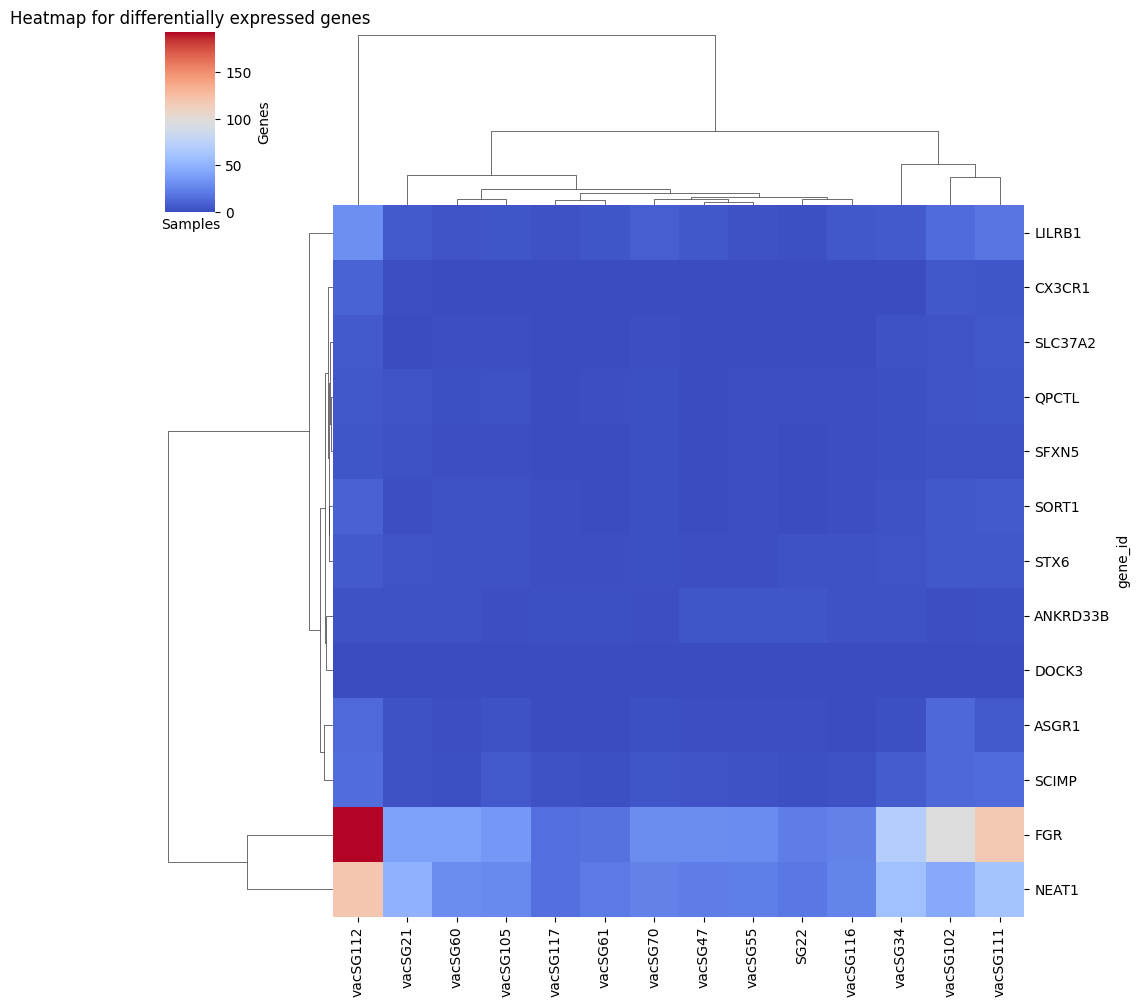

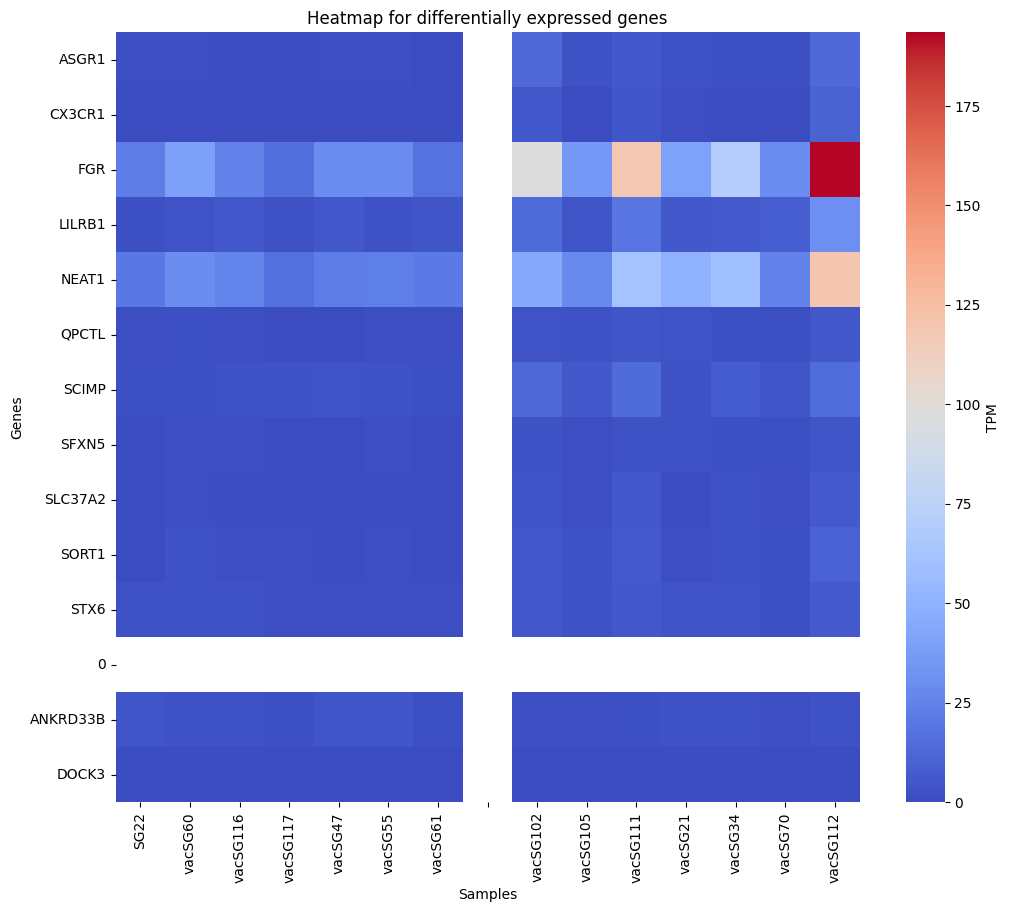

In [27]:
#########################
######   TASK 6   #######
#     Draw heatmap      #
#########################
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
# plot heatmap
sns.clustermap(
    tpm_sig,
    cmap="coolwarm",      # red = high, blue = low
    yticklabels=True,
    xticklabels=True,
    cbar_kws={'label': 'TPM'}
)
plt.title("Heatmap for differentially expressed genes")
plt.ylabel("Genes")
plt.xlabel("Samples")
plt.show()

plt.figure(figsize=(12,10))
# plot heatmap
sns.heatmap(
    tpm_sig_gap,
    cmap="coolwarm",      # red = high, blue = low
    yticklabels=True,
    xticklabels=True,
    cbar_kws={'label': 'TPM'}
)
plt.title("Heatmap for differentially expressed genes")
plt.ylabel("Genes")
plt.xlabel("Samples")
plt.show()

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#########################
######   TASK 7   #######
#    Prepare for PCA    #
#########################

# get significant gene dataframe and transpose it for PCA
tpm_sig = pd.concat([tpm_down, tpm_up]).T
tpm_sig.head()

# scale the values
X = tpm_sig.values
tpm_sig_stand = StandardScaler().fit_transform(X)

# calculate PCA with 2 components
pca = PCA(n_components=2)  # first 2 principal components
principalComponents = pca.fit_transform(tpm_sig_stand)




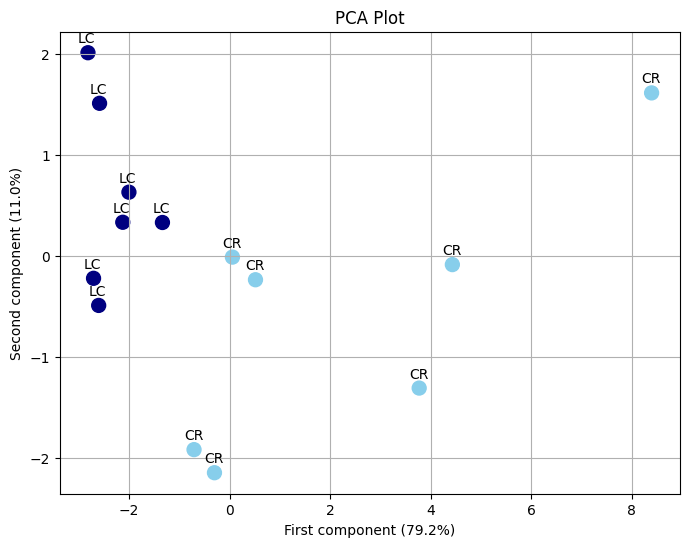

In [15]:
#########################
######   TASK 8   #######
#       Plot PCA        #
#########################

# Convert to DataFrame for plotting
pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

#add sample names
pca_df['Sample'] = tpm_sig.index 

#add group and delete duplicated column
merged = pd.merge(pca_df, clinical_data, left_on="Sample", right_on="sampleName", how="inner")
merged = merged.drop(columns="sampleName")

# map group to colors
colors = {'LC':'navy', 'CR':'skyblue'}  

plt.figure(figsize=(8,6))
# make scatterplot from PC1 and PC2, colored in condition
plt.scatter(merged['PC1'], merged['PC2'], c=merged['Condition'].map(colors), s=100)
# add x and y label (formatted string including explained variance ratio)
plt.xlabel(f"First component ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Second component ({pca.explained_variance_ratio_[1]*100:.1f}%)")
# include labels for each point
for i in range(merged.shape[0]):
    plt.text(merged['PC1'][i]-0.2, merged['PC2'][i]+0.1, merged['Condition'][i], fontsize=10)
# add title 
plt.title("PCA Plot")
plt.grid(True)
plt.show()

In [16]:
#########################
######   TASK 9   #######
#      Plot S1PR1       #
#########################

# plot S1PR1, therefor extract the TPM values for that gene
tpm_S1PR1 = tpm_table.loc["S1PR1"]
tpm_S1PR1
# merge the values with the clinical data
tpm_S1PR1_merged = pd.merge(tpm_S1PR1, clinical_data, 
                            left_index=True, right_on="sampleID", how="inner")
tpm_S1PR1_merged

,S1PR1,sampleName,sampleID,Condition
2,34.598149,vacSG111,SRR31535847,CR
1,34.560771,vacSG105,SRR31535848,CR
0,12.252166,vacSG102,SRR31535849,CR
4,36.432347,vacSG70,SRR31535850,CR
9,54.065398,vacSG61,SRR31535851,LC
7,50.622411,vacSG55,SRR31535852,LC
6,48.854164,vacSG47,SRR31535853,LC
5,62.692822,vacSG34,SRR31535854,CR
8,116.911504,vacSG60,SRR31535855,LC
12,62.012303,vacSG117,SRR31535856,LC


In [17]:
from scipy import stats


# Force conversion to numeric
tpm_S1PR1_merged['S1PR1'] = pd.to_numeric(tpm_S1PR1_merged['S1PR1'], errors='coerce')

# make two groups for statistical test
group1 = tpm_S1PR1_merged[tpm_S1PR1_merged['Condition']=='CR']['S1PR1']
group2 = tpm_S1PR1_merged[tpm_S1PR1_merged['Condition']=='LC']['S1PR1']

# test for difference in mean (T-test)
t_stat, p_val = stats.ttest_ind(group1, group2)
print("p-value:", p_val)

p-value: 0.012388270686041591


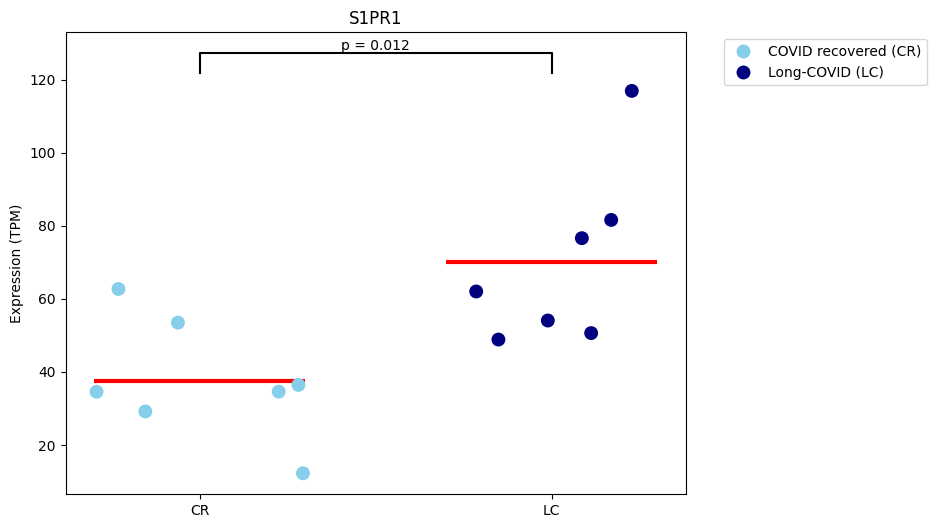

In [18]:
#########################
######   TASK 10  #######
#      Plot S1PR1       #
#########################

plt.figure(figsize=(8,6))
# make stripplot with S1PR1 expression values
sns.stripplot(x='Condition',y='S1PR1',data=tpm_S1PR1_merged,hue='Condition',
              palette=colors,jitter=0.3,dodge=False,size=10, legend=True)

#include meanbar for each group
bar_width = 0.3
for xi, group in enumerate(tpm_S1PR1_merged.groupby('Condition')):
    mean_y = group[1]['S1PR1'].mean()
    plt.hlines(y=mean_y, xmin=xi-bar_width, xmax=xi+bar_width, color='red', linewidth=3)

    
# Add significance annotation
x1, x2 = 0, 1  # positions of the groups on x-axis
y, h, col = tpm_S1PR1_merged['S1PR1'].max() + 10, 0.3, 'k'  # y-position, height of line, color
plt.plot([x1, x1, x2, x2], [y-5, y+h, y+h, y-5], lw=1.5, c=col)  # draw bracket
plt.text((x1+x2)*.5, y+h, f"p = {p_val:.3f}", ha='center', va='bottom', color=col)

plt.ylabel("Expression (TPM)")
plt.xlabel("")
plt.title("S1PR1")
plt.grid(False)
legend = plt.legend(bbox_to_anchor=(1.05,1), loc=2)
legend.get_texts()[0].set_text("COVID recovered (CR)")
legend.get_texts()[1].set_text("Long-COVID (LC)")
plt.show()


Index(['ANKRD33B', 'ASGR1', 'CX3CR1', 'DOCK3', 'FGR', 'LILRB1', 'NEAT1',
       'QPCTL', 'SCIMP', 'SFXN5', 'SLC37A2', 'SORT1', 'STX6'],
      dtype='str', name='gene_id')
   source      native                                               name  \
0   GO:CC  GO:0031259                                    uropod membrane   
1   GO:CC  GO:0031257                        cell trailing edge membrane   
2   GO:BP  GO:0048011        neurotrophin TRK receptor signaling pathway   
3   GO:CC  GO:0160056                             macropinosome membrane   
4   GO:CC  GO:0016020                                           membrane   
5   GO:MF  GO:0016495                 C-X3-C chemokine receptor activity   
6   GO:MF  GO:0030379  neurotensin receptor activity, non-G protein-c...   
7   GO:CC  GO:0031090                                 organelle membrane   
8   GO:MF  GO:0016603       glutaminyl-peptide cyclotransferase activity   
9   GO:MF  GO:0061513  glucose 6-phosphate:phosphate antiporter activ

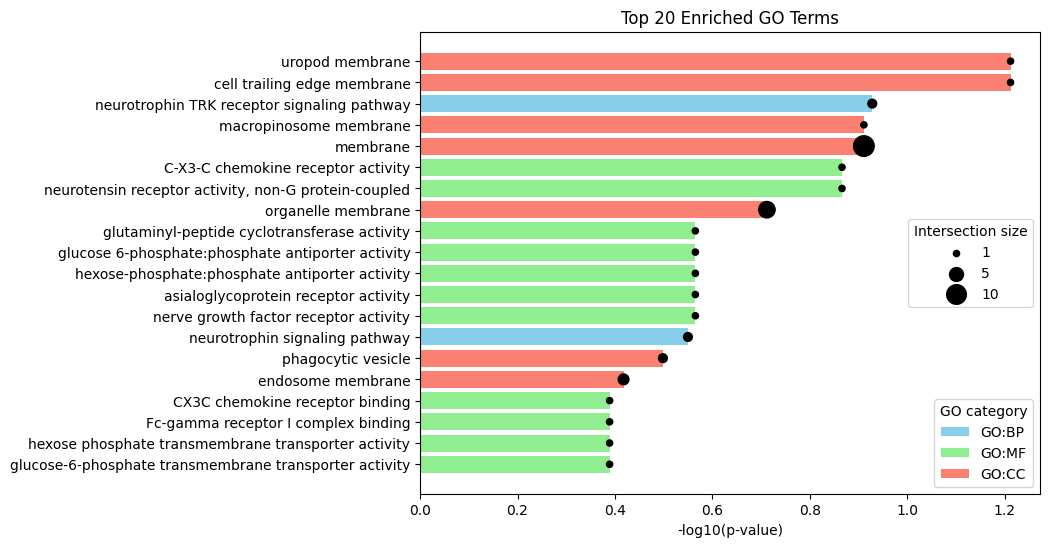

In [25]:
from gprofiler import GProfiler
from matplotlib.patches import Patch

#########################
######   TASK 11  #######
#     GO ananlysis      #
#########################

# get names of significantly expressed genes
sigGenesAll = res[res["padj"] < 0.05]
sigGenesAll = sigGenesAll.index
print(sigGenesAll)

#initialize GProfiler
gp = GProfiler(return_dataframe=True)

# Run enrichment for human genes
go_results = gp.profile(
    organism='hsapiens',
    query=list(sigGenesAll),
    sources=['GO:CC','GO:BP','GO:MF'],
    user_threshold=0.05,
    all_results=True
)

# set different colors for GO:BP,GO:MF,GO:CC
colors = {
    'GO:BP': 'skyblue',
    'GO:MF': 'lightgreen',
    'GO:CC': 'salmon'
}

size_scale = 20

# get the top 20 results from GO analysis
top_terms = go_results.head(20)
print(top_terms)
# plot -log10(pvalue) and name of GO term with color-coded bars
bar_colors = [colors[src] for src in top_terms['source']]

plt.figure(figsize=(8,6))
plt.barh(
    top_terms['name'], 
    -np.log10(top_terms['p_value']), 
    color=bar_colors
)

plt.scatter(
    -np.log10(top_terms['p_value']),                          # x-position = end of bar
    top_terms['name'],             # y-position
    s=top_terms['intersection_size'] * 20,  # scale marker sizes
    color='black',
    zorder=3
)

plt.xlabel('-log10(p-value)')
plt.title('Top 20 Enriched GO Terms')
plt.gca().invert_yaxis()  # largest bar on top


# --- GO category legend ---
color_legend = [
    Patch(facecolor=c, label=l)
    for l, c in colors.items()
]

legend1 = plt.legend(
    handles=color_legend,
    title='GO category',
    loc='lower right'
)

# Keep first legend when adding second
plt.gca().add_artist(legend1)

# --- Point size legend ---
size_values = [1, 5, 10]  # example intersection sizes

size_legend = [
    plt.scatter([], [], 
                s=v * size_scale,
                color='black',
                label=str(v))
    for v in size_values
]

plt.legend(
    handles=size_legend,
    title='Intersection size',
    loc='center right',
    scatterpoints=1
)


plt.show()
